In [10]:
# ── 1. Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load the cleaned dataset
df = pd.read_csv('../Level1 Task2_EDA/Amazon Sale Report.csv', low_memory=False)

# Quick clean for this task
df = df.dropna(subset=['Amount', 'Qty'])
df = df[df['Amount'] > 0]
df = df[df['Qty'] > 0]

print("Shape:", df.shape)
df[['Qty', 'Amount']].describe()

Shape: (113701, 24)


,Qty,Amount
count,113701.000000,113701.000000
mean,1.003852,663.164845
std,0.073385,269.538074
min,1.000000,199.000000
25%,1.000000,459.000000
50%,1.000000,625.000000
75%,1.000000,788.000000
max,8.000000,5584.000000


In [11]:
# ── 2. Define Features and Target ────────────────────────────
X = df[['Qty']]         # feature: quantity ordered
y = df['Amount']        # target: sale amount

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 90960
Testing samples: 22741


In [12]:
# ── 3. Fit Linear Regression Model ───────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficient (slope):", round(model.coef_[0], 2))
print("Intercept:", round(model.intercept_, 2))
print("\nInterpretation: For every 1 unit increase in Qty,")
print(f"Amount increases by {round(model.coef_[0], 2)} INR")

Coefficient (slope): 525.01
Intercept: 135.78

Interpretation: For every 1 unit increase in Qty,
Amount increases by 525.01 INR


In [13]:
# ── 4. Evaluate the Model ─────────────────────────────────────
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R-squared:", round(r2, 4))
print("Mean Squared Error:", round(mse, 2))
print("RMSE:", round(rmse, 2))

R-squared: 0.0408
Mean Squared Error: 71055.15
RMSE: 266.56


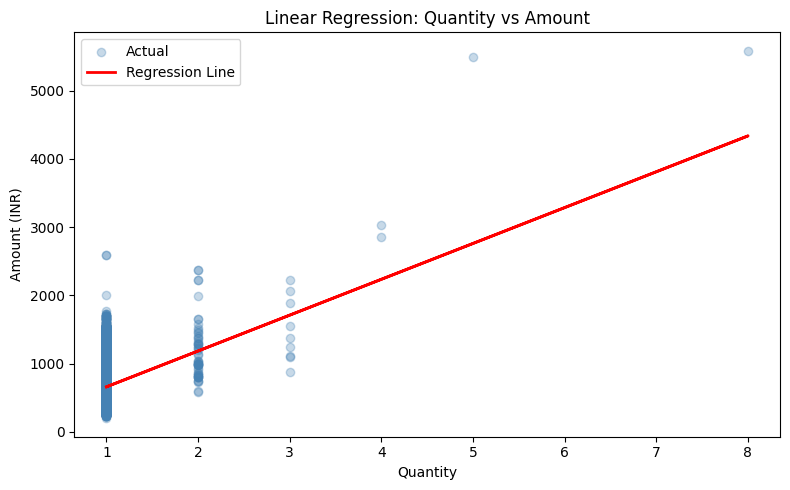

Plot saved.


In [14]:
# ── 5. Visualize Results ──────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.3, label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Quantity')
plt.ylabel('Amount (INR)')
plt.title('Linear Regression: Quantity vs Amount')
plt.legend()
plt.tight_layout()
plt.savefig('regression_plot.png', dpi=300)
plt.show()
print("Plot saved.")